In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.datasets import mnist

## 1. image data load

In [3]:
(X_train,y_train),(X_test,y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


- **mnist** dataset은 **0부터 9**까지 gray scale의 손글씨 image
- **X**는 image data, **y**는 해당 image에 대한 label(0~9)

In [4]:
print(X_train.shape, X_test.shape)

(60000, 28, 28) (10000, 28, 28)


- **X_train.shape = (60000,28,28)**: 가로 28 픽셀, 세로 28 픽셀 크기의 image 60000장 이라는 의미
- **X_train[0]** 은 **X_train**의 첫번째 image를 의미함

- **plt.imshow(image,cmap)**: 전달받은 이미지를 확인할 수 있음 (`cmap`은 color map을 의미함(ex> rgb,hsv,gray,...))

5


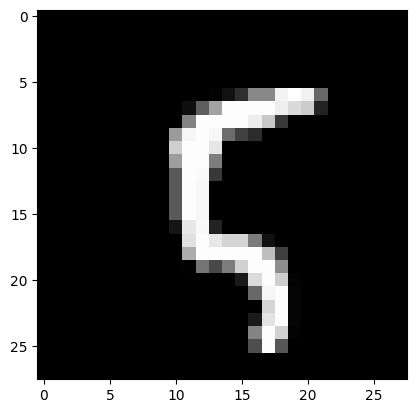

In [7]:
plt.imshow(X_train[100],cmap='gray')
print(y_train[100])

## 2. image data 변환

- image는 0(black)부터 255(white)까지의 값을 가지고 있으며, 이 범위를 0부터 1까지로 변경함
- 최대값이 255이므로 각 pixel의 값을 255로 나눔

In [9]:
X_train = X_train/255
X_test = X_test/255

- **ANN**의 **Dense** layer와 연결할 수 있도록 **28x28**인 2d image를 1d data로 변환함
- **ndarray.reshape(a,b)**: ndarray의 shape을 (a,b)로 변경함
- **(60000,28,28)** 인 **X_train**을 **(60000,784)** 로, **(10000,28,28)** 인 **X_test**을 **(10000,784)** 로 변경함

In [12]:
X_train = X_train.reshape(60000,784)
X_test = X_test.reshape(10000,784)

In [13]:
print(X_train.shape, X_test.shape)

(60000, 784) (10000, 784)


## 3. **y_train, y_test** 확인
- **y_train**과 **y_test**는 One-Hot Encoding이 된 형태가 아니므로, 몇개의 값으로 구성되어있는지(몇개의 class)인지 확인이 필요함
- **np.unique(ndarray)** 는 ndarray에 어떠한 값을 포함되어 있는지 반환함

In [15]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

- **y_train**이 0~9까지 값을 포함하고 있음을 확인할 수 있음
- 총 10개의 class이므로 output layer의 node는 10개로 설정해야 함

## 4. ANN structure

In [ ]:
# 2개의 hidden layer로 구성하되
# hidden layer node의 수는 각각 512, 128로 함
ann_image = Sequential([
    # input layer
    Input(),
    # hidden layer1
    Dense(),
    # hidden layer2
    Dense(),
    # output layer
    Dense()
])

## 5. ANN 학습

In [ ]:
ann_image.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  # y가 One-Hot Encoding이 된 형태가 아닌 0~9까지의 정수이므로
                  # 'sparse_categorical_crossentropy'를 사용함
                  metrics=['acc'])

In [ ]:
# epochs: 15-20
# batch_size: 512 또는 1024
# validation_split: 0.3
train_result = ann_image.fit()

## 6. ANN 학습 결과 시각화 및 test data에 대한 성능 평가

In [ ]:
# training data의 loss 및 validation data의 loss 시각화


In [ ]:
# X_test를 통한 성능 평가
